# Project 2：NASA Data Acquisation, Visualization, and Analysis
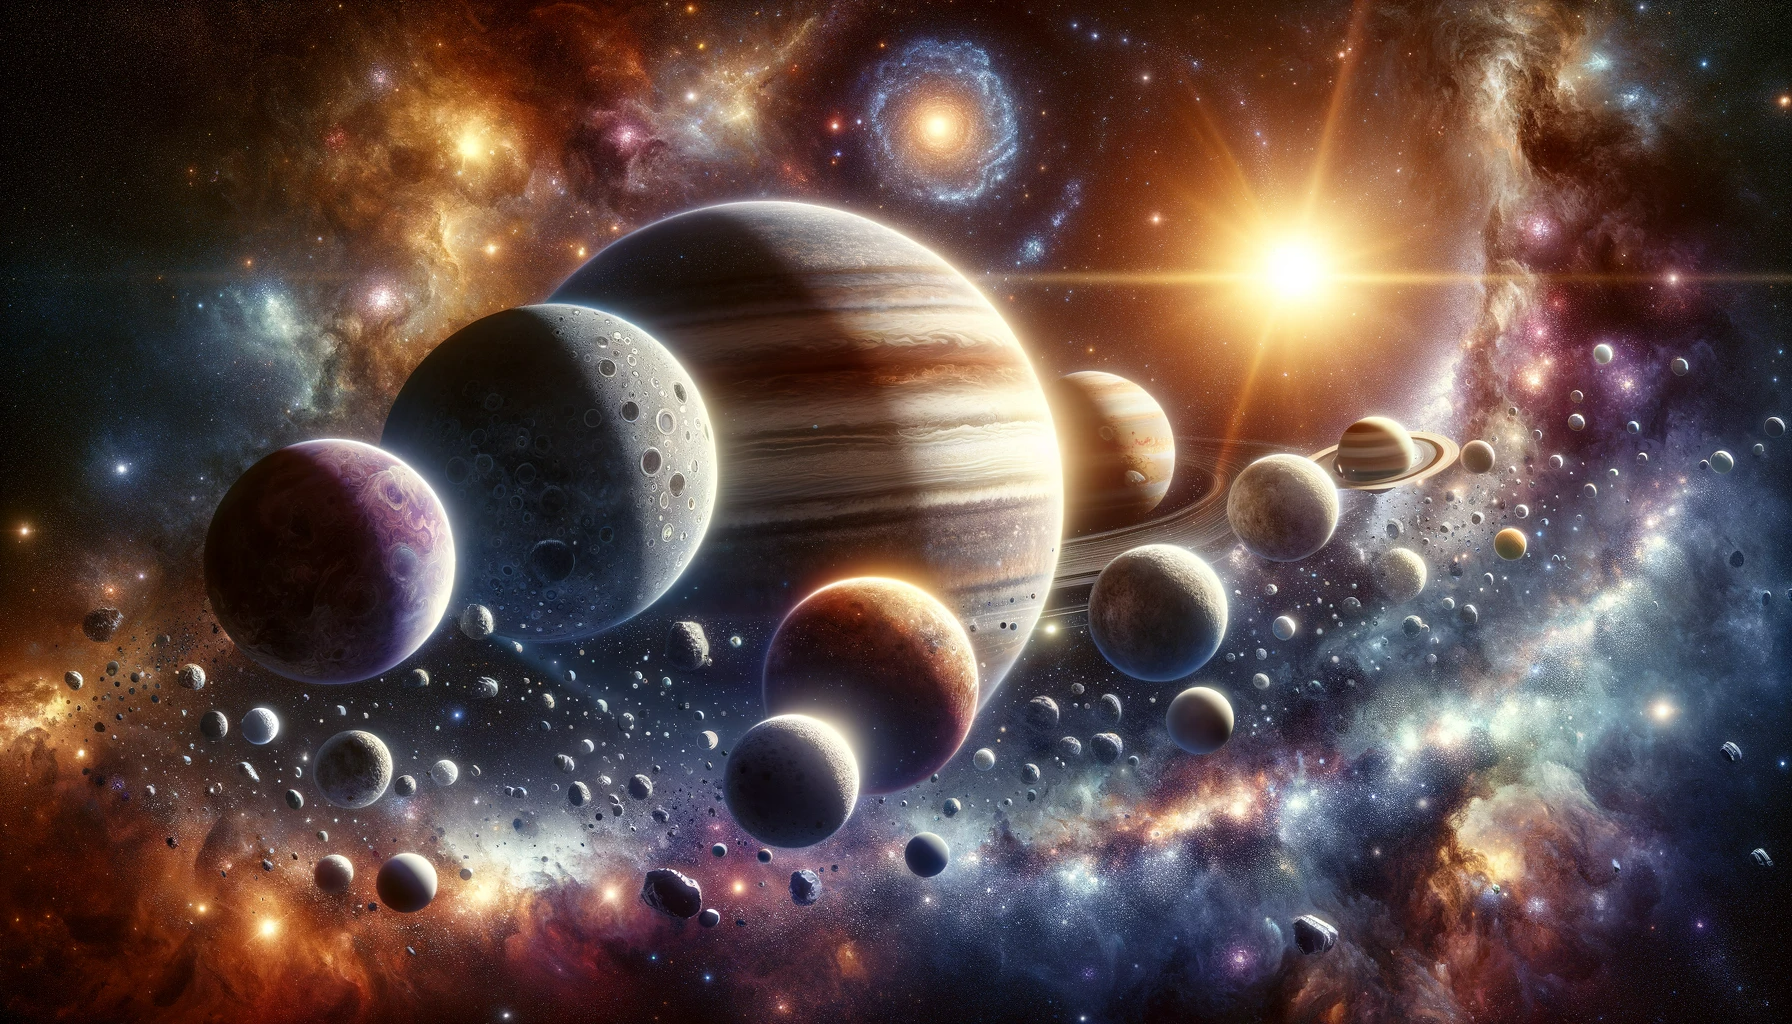

In [111]:
# The code makes sure that once there is change in the 'src/' folder, the 
# change will be automatically reloaded in the notebook.
%reload_ext autoreload
%autoreload 2
%aimport src

### Task 1: Understanding the NASA API and Data Collection

- Run the Python script below to fetch data about **Near Earth Objects (NEOs)**.
- Extract and understand the different pieces of data provided for each NEO.

In [112]:
import sys
import subprocess

# Function to install a package
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Check if gdown is installed, and install it if not
try:
    import gdown
except ImportError:
    install('gdown')
    import gdown

import pickle

In [113]:
# Google Drive file ID
file_id = '1iW47qh3E2ccZVQ4fOs9-UP0xNEjhNae2'
# URL to the file
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Output file name
output = 'file.pkl'

# Download the file
gdown.download(url, output, quiet=False)

# Load the pickle file
with open(output, 'rb') as f:
    data = pickle.load(f)

Downloading...
From: https://drive.google.com/uc?id=1iW47qh3E2ccZVQ4fOs9-UP0xNEjhNae2
To: c:\Users\hanso\Deto_Emp\DTU\62444\62444-Project-Course-main\62444-Project-Course-main\file.pkl
100%|██████████| 5.26M/5.26M [00:00<00:00, 8.84MB/s]


*The code (commented out) below is for getting the data for arbitrary time span. If you would like some other data rather than the provided data above, feel free to try. But this is not mandatory.*

In order to use it, you need to get an API KEY from the website https://api.nasa.gov/.


### Data acquisition and initial inspection

In this task, the provided NASA NEO dataset is loaded and inspected. The data contains Near Earth Objects grouped by date. Each NEO includes information such as estimated diameter, whether it is potentially hazardous, close approach distance, and relative velocity.

The API data is nested, so it is not immediately ready for analysis in Pandas. Therefore, the next task focuses on extracting the relevant fields and organizing them into a clean DataFrame.

In [114]:
# import requests
# import time
# from datetime import datetime, timedelta
# from getpass import getpass

# # Set your NASA API KEY, this step asks you to enter your API KEY.
# # (The input box may be float in the top on your editor.)
# api_key = getpass()

In [115]:
# # Set the start and end dates for the data you want to fetch
# start_date = datetime.strptime('2022-01-01', '%Y-%m-%d')
# end_date = start_date + timedelta(days=365)  # 1 year later

# # Initialize a list to store the data
# data = []

# # Fetch data from the NASA API 7 days at a time
# # The introduction of the API is on https://api.nasa.gov, under "Browse APIs" -> "Asteroids NeoWs"
# # You can look into the example query in the link below to see what the data look like:
# # https://api.nasa.gov/neo/rest/v1/feed?start_date=2015-09-07&end_date=2015-09-08&api_key=DEMO_KEY
# current_date = start_date
# while current_date < end_date:
#     next_date = min(current_date + timedelta(days=7), end_date)
#     response = requests.get(f'https://api.nasa.gov/neo/rest/v1/feed?start_date={current_date.strftime("%Y-%m-%d")}&end_date={next_date.strftime("%Y-%m-%d")}&api_key={api_key}')
#     data.append(response.json())
#     current_date = next_date
#     time.sleep(1)  # To avoid hitting the rate limit

# # Now 'data' contains the NEO data for the 1-year period


In [116]:
# Check the date coverage of your data.
dates_contained_in_data = []
for d in data:
    dates_contained_in_data += list(d['near_earth_objects'].keys())

print(sorted(dates_contained_in_data))

['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04', '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08', '2022-01-08', '2022-01-09', '2022-01-10', '2022-01-11', '2022-01-12', '2022-01-13', '2022-01-14', '2022-01-15', '2022-01-15', '2022-01-16', '2022-01-17', '2022-01-18', '2022-01-19', '2022-01-20', '2022-01-21', '2022-01-22', '2022-01-22', '2022-01-23', '2022-01-24', '2022-01-25', '2022-01-26', '2022-01-27', '2022-01-28', '2022-01-29', '2022-01-29', '2022-01-30', '2022-01-31', '2022-02-01', '2022-02-02', '2022-02-03', '2022-02-04', '2022-02-05', '2022-02-05', '2022-02-06', '2022-02-07', '2022-02-08', '2022-02-09', '2022-02-10', '2022-02-11', '2022-02-12', '2022-02-12', '2022-02-13', '2022-02-14', '2022-02-15', '2022-02-16', '2022-02-17', '2022-02-18', '2022-02-19', '2022-02-19', '2022-02-20', '2022-02-21', '2022-02-22', '2022-02-23', '2022-02-24', '2022-02-25', '2022-02-26', '2022-02-26', '2022-02-27', '2022-02-28', '2022-03-01', '2022-03-02', '2022-03-03', '2022-03-04', '2022

In [117]:
from src.utils import get_a_random_chunk_property

In [118]:
get_a_random_chunk_property(data)

date: 2022-08-06
NEO name: (1997 CD17)
name: (1997 CD17)


### Task 2: Data Analysis

For the remaining tasks, you have to organize the data as pd.DataFrame so as to suit the specific need in each task. This part may require a considerably amount of efforts, which is normal in data science and analytics works.

**Remark**. This part is **coding intensive**. There is **NOT** any magic way to extract the data by one or two lines of code. Instead, you're expected to write your own code for this purpose.

- Calculate the average size of the NEOs for each day.（You have to fetch the corresponding each day's NEO size information from "data" by writing your own code)
- Determine the proportion of NEOs that are potentially hazardous.
- Find the NEO with the closest approach distance for each day.
- Use statistical methods to analyze the data. Calculate the mean, median, mode, and standard deviation of the NEO sizes. Besides, define at least two other statistic and compute them for anlayzing the data further. 
- Use statistical methods to determine if the size of a NEO is correlated with whether it is potentially hazardous.

In [119]:
# Write your code and markdowns

## Creating the NEO DataFrame

The original NASA NEO data is stored in a nested structure where the observations are grouped by date. To make the data easier to analyze, we convert the relevant information into a Pandas DataFrame.

Each row in the DataFrame represents one near-Earth object observation. The selected columns include the date, object name, hazardous classification, estimated minimum and maximum diameter, average diameter, miss distance, and relative velocity.

The average diameter is calculated from the minimum and maximum estimated diameter. This gives a single representative size value for each NEO, which can be used in the later statistical analysis.

In [120]:
import pandas as pd
import numpy as np

rows = []

# for loop - Loops through each date, then each NEO on that date,
# extracts useful values like 
# name, hazardous status, diameter, miss distance, velocity, 
# calculates the average diameter, and saves everything in a structured row.
for chunk in data:
    neo_by_date = chunk["near_earth_objects"]
    
    for date, neos in neo_by_date.items():
        for neo in neos:
            close_data = neo["close_approach_data"][0]
            
            diameter_min = neo["estimated_diameter"]["kilometers"]["estimated_diameter_min"]
            diameter_max = neo["estimated_diameter"]["kilometers"]["estimated_diameter_max"]
            diameter_avg = (diameter_min + diameter_max) / 2
            
            rows.append({
                "date": date,
                "name": neo["name"],
                "is_hazardous": neo["is_potentially_hazardous_asteroid"],
                "diameter_min_km": diameter_min,
                "diameter_max_km": diameter_max,
                "diameter_avg_km": diameter_avg,
                "miss_distance_km": float(close_data["miss_distance"]["kilometers"]),
                "relative_velocity_kmh": float(close_data["relative_velocity"]["kilometers_per_hour"])
            })

neo_df = pd.DataFrame(rows)

# Make sure date is datetime
neo_df["date"] = pd.to_datetime(neo_df["date"])

rows_before = len(neo_df)

# Remove duplicate NEO observations
neo_df = neo_df.drop_duplicates(
    subset=["date", "name", "miss_distance_km"],
    keep="first"
).copy()
rows_after = len(neo_df)

# Print result
duplicates_removed = rows_before - rows_after
duplicate_percentage = (duplicates_removed / rows_before) * 100

print(f"Duplicates removed: {rows_before - rows_after} out of {rows_before} ({duplicate_percentage:.2f}%)")

neo_df.head()


Duplicates removed: 1002 out of 7914 (12.66%)


,date,name,is_hazardous,diameter_min_km,diameter_max_km,diameter_avg_km,miss_distance_km,relative_velocity_kmh
0,2022-01-07,216523 (2001 HY7),True,0.192555,0.430566,0.311561,5.805761e+07,46843.878573
1,2022-01-07,494697 (2004 SW55),True,0.186447,0.416908,0.301677,2.002677e+07,36172.079029
2,2022-01-07,496860 (1999 XL136),True,0.308003,0.688716,0.498359,1.339610e+07,60344.757500
3,2022-01-07,(2006 AL4),False,0.027578,0.061665,0.044621,1.423920e+07,34048.656251
4,2022-01-07,(2008 CO),False,0.080270,0.179490,0.129880,3.093477e+07,16072.436097


## Average NEO size for each day

To calculate the average size of the NEOs for each day, we group the DataFrame by date and calculate the mean of the average diameter column.

This produces one average diameter value for each date in the dataset. The result shows how the typical estimated NEO size varies from day to day during the analyzed period.

In [122]:

average_size_each_day = neo_df.groupby("date")["diameter_avg_km"].mean().reset_index()
average_size_each_day

,date,diameter_avg_km
0,2022-01-01,0.164070
1,2022-01-02,0.113284
2,2022-01-03,0.028179
3,2022-01-04,0.080179
4,2022-01-05,0.177149
...,...,...
361,2022-12-28,0.125473
362,2022-12-29,0.153640
363,2022-12-30,0.137482
364,2022-12-31,0.052291


## Proportion of potentially hazardous NEOs

The proportion of potentially hazardous NEOs is calculated using the `is_hazardous` column. Since this column contains Boolean values, where `True` is treated as 1 and `False` as 0, taking the mean gives the fraction of NEOs that are potentially hazardous.

The result shows that approximately **6.66%** of the observed NEOs are classified as potentially hazardous. This means that most NEOs in the dataset are not considered potentially hazardous.

In [124]:
hazardous_counts = neo_df["is_hazardous"].value_counts(normalize=True).reset_index()
hazardous_counts.columns = ["is_hazardous", "proportion"]

hazardous_counts

,is_hazardous,proportion
0,False,0.933449
1,True,0.066551


## Closest NEO for each day

To find the closest NEO for each day, we group the DataFrame by date and select the object with the smallest miss distance for each group.

This gives one NEO per day: the object that passed closest to Earth on that specific date. The result includes the name, miss distance, average diameter, and whether the object was classified as potentially hazardous.

In [ ]:
#creating a list of NEOs closest to the earth for each day
closest_neo_each_day = neo_df.loc[
    neo_df.groupby("date")["miss_distance_km"].idxmin()
].reset_index(drop=True)

closest_neo_each_day[["date", "name", "miss_distance_km", "diameter_avg_km", "is_hazardous"]]

,date,name,miss_distance_km,diameter_avg_km,is_hazardous
0,2022-01-01,(2022 AJ1),7.705295e+05,0.011522,False
1,2022-01-02,(2022 AP1),1.805971e+05,0.009027,False
2,2022-01-03,(2022 AU),3.185179e+05,0.006420,False
3,2022-01-04,(2022 AT1),2.041259e+06,0.024521,False
4,2022-01-05,(2022 AV13),1.094803e+05,0.001860,False
...,...,...,...,...,...
361,2022-12-28,(2023 AB),2.600532e+06,0.043007,False
362,2022-12-29,(2022 YT6),2.282264e+06,0.025325,False
363,2022-12-30,(2022 YG5),3.122485e+06,0.019388,False
364,2022-12-31,(2023 AW),1.484770e+06,0.030587,False


## Descriptive statistics of NEO sizes

To summarize the distribution of NEO sizes, we calculate the mean, median, mode, and standard deviation of the average diameter.

The mean NEO diameter is approximately **0.149 km**, while the median is approximately **0.056 km**. Since the mean is larger than the median, this suggests that the dataset contains some large NEOs that pull the average upward.

The standard deviation is approximately **0.286 km**, which shows that there is a large amount of variation in the estimated NEO sizes.

In [126]:
size_mean = neo_df["diameter_avg_km"].mean()
size_median = neo_df["diameter_avg_km"].median()
size_mode = neo_df["diameter_avg_km"].mode()[0]
size_std = neo_df["diameter_avg_km"].std()

size_statistics = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode", "Standard deviation"],
    "Value": [size_mean, size_median, size_mode, size_std]
})

size_statistics

,Statistic,Value
0,Mean,0.148834
1,Median,0.055660
2,Mode,0.034162
3,Standard deviation,0.285743


## Additional statistics of NEO sizes

In addition to the required statistics, we calculate the minimum, maximum, range, quartiles, and interquartile range.

The smallest NEO has an average estimated diameter of approximately **0.001 km**, while the largest has an average estimated diameter of approximately **4.984 km**. This gives a very large range, showing that the dataset contains both very small and very large objects.

The interquartile range is approximately **0.124 km**, meaning that the middle 50% of NEO sizes are within a much smaller interval than the full range. This suggests that most NEOs are relatively small, while a few very large objects act as outliers.

In [127]:
size_min = neo_df["diameter_avg_km"].min()
size_max = neo_df["diameter_avg_km"].max()
size_range = size_max - size_min
size_q1 = neo_df["diameter_avg_km"].quantile(0.25)
size_q3 = neo_df["diameter_avg_km"].quantile(0.75)
size_iqr = size_q3 - size_q1

extra_statistics = pd.DataFrame({
    "Statistic": ["Minimum", "Maximum", "Range", "Q1", "Q3", "IQR"],
    "Value": [size_min, size_max, size_range, size_q1, size_q3, size_iqr]
})

extra_statistics

,Statistic,Value
0,Minimum,0.001105
1,Maximum,4.983594
2,Range,4.982488
3,Q1,0.025914
4,Q3,0.149811
5,IQR,0.123896


## Correlation between NEO size and hazardousness

To investigate whether larger NEOs are more likely to be classified as potentially hazardous, we calculate the correlation between the average diameter and the numeric hazardousness value.

The correlation is approximately **0.275**, which is positive. This suggests that larger NEOs are more likely to be classified as potentially hazardous, although the relationship is not extremely strong.

In [128]:
neo_df["hazardous_numeric"] = neo_df["is_hazardous"].astype(int)

correlation = neo_df["diameter_avg_km"].corr(neo_df["hazardous_numeric"])

if correlation > 0:
    direction = "positive"
    meaning = "larger NEOs tend to be more likely to be potentially hazardous"
elif correlation < 0:
    direction = "negative"
    meaning = "larger NEOs tend to be less likely to be potentially hazardous"
else:
    direction = "no"
    meaning = "there is no linear relationship between size and hazardousness"

strength = (
    "very weak" if abs(correlation) < 0.10 else
    "weak" if abs(correlation) < 0.30 else
    "moderate" if abs(correlation) < 0.50 else
    "strong"
)

print(f"Correlation: {correlation:.3f}")
print(f"The correlation is {direction} and {strength}.")
print(f"This means that {meaning}.")

Correlation: 0.275
The correlation is positive and weak.
This means that larger NEOs tend to be more likely to be potentially hazardous.


## Comparing hazardous and non-hazardous NEO sizes

To better understand the relationship between NEO size and hazardousness, we compare the size statistics for hazardous and non-hazardous NEOs separately.

We group the DataFrame by the `is_hazardous` column and calculate the count, mean, median, standard deviation, minimum, and maximum average diameter for each group.

This makes it easier to see whether potentially hazardous NEOs are generally larger than non-hazardous NEOs. If the hazardous group has a higher mean and median diameter, it supports the idea that larger NEOs are more likely to be classified as potentially hazardous.

In [129]:
hazardous_size_comparison = neo_df.groupby("is_hazardous")["diameter_avg_km"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).reset_index()

hazardous_size_comparison

,is_hazardous,count,mean,median,std,min,max
0,False,6452,0.127871,0.050297,0.265176,0.001105,4.983594
1,True,460,0.442870,0.310132,0.385039,0.159053,2.934557


**Textbook Practice**: Make a visualization as an evidence for your conclusion on the hazardousness. Apply the principle of "choosing an effective visual" in Chapter 2 to make this visualization. You need to explain how the principles below are used for making this plot:
- "Choose an appropriate display" (Chapter 2)
- "Eliminate clutter" (Chapter 3)
- "Draw attention there you want it" (Chapter 4)
- "Think like a designer" (Chapter 5)

In [150]:
# Write your code or/and markdowns

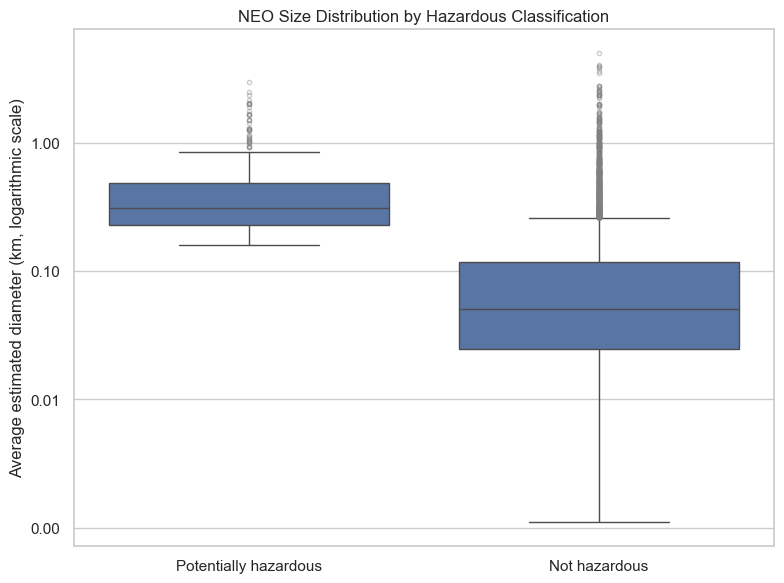

,is_hazardous,count,mean,median,std,min,max
0,False,6452,0.127871,0.050297,0.265176,0.001105,4.983594
1,True,460,0.442870,0.310132,0.385039,0.159053,2.934557


In [151]:
#%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

plot_df = neo_df.copy()

plot_df["Hazardous"] = plot_df["is_hazardous"].map({
    False: "Not hazardous",
    True: "Potentially hazardous"
})

plt.figure(figsize=(8, 6))

ax = sns.boxplot(
    data=plot_df,
    x="Hazardous",
    y="diameter_avg_km",
    flierprops={
        "marker": "o",
        "markersize": 3,
        "markerfacecolor": "none",
        "markeredgecolor": "gray",
        "alpha": 0.4
    }
)

plt.yscale("log")

ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="y", style="plain")

plt.title("NEO Size Distribution by Hazardous Classification")
plt.xlabel("")
plt.ylabel("Average estimated diameter (km, logarithmic scale)")

plt.tight_layout()
plt.show()

hazardous_summary = neo_df.groupby("is_hazardous")["diameter_avg_km"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).reset_index()

hazardous_summary

### Visualization evidence for hazardousness

The boxplot compares the average estimated diameter of NEOs classified as potentially hazardous with those classified as not hazardous. This supports the conclusion that potentially hazardous NEOs tend to be larger on average. The plot uses a logarithmic y-axis because NEO sizes are highly skewed, with some objects being much larger than most others.

**Choose an appropriate display:**  
A boxplot is appropriate because the goal is to compare the distribution of a numerical variable, NEO size, across two categories: hazardous and non-hazardous. It shows the median, spread, and outliers more clearly than a simple bar chart.

**Eliminate clutter:**  
The plot only includes the two relevant groups and one key measurement, average diameter. Unnecessary visual elements are avoided so the comparison is easy to read.

**Draw attention where you want it:**  
The x-axis separates the two hazardousness categories clearly, making the size difference between the groups the main focus. The log-scaled y-axis helps make the comparison visible even though the data contains very large outliers.

**Think like a designer:**  
The title, axis labels, and simplified layout make the message clear without requiring extra explanation. The plot is designed to communicate one main insight: potentially hazardous NEOs are generally larger than non-hazardous NEOs.

### Task 3: Data Visualization Part A

- Create a line plot of the number of NEOs per week.
- Create a histogram of the distribution of NEO sizes.
- Create a bar plot of the average NEO size per week.
- Use a library like Seaborn to create more complex visualizations, such as a box plot of the NEO sizes or a heat map of the number of NEOs per week. **Be creative**!

In [152]:
# Write your code and markdowns

### Weekly NEO aggregation

We convert the date column to datetime format and then group the NEO data by week.  
This lets us calculate the number of NEOs observed each week and their average diameter.

In [39]:
neo_df["date"] = pd.to_datetime(neo_df["date"])

weekly_neo_count = neo_df.groupby(pd.Grouper(key="date", freq="W")).size().reset_index(name="neo_count")

weekly_avg_size = neo_df.groupby(pd.Grouper(key="date", freq="W"))["diameter_avg_km"].mean().reset_index(name="average_diameter_km")

### Weekly NEO count plot

We remove the first week because it may be incomplete, then plot the number of NEOs observed each week.  
This helps show how NEO observations change over time without the first partial week affecting the trend.

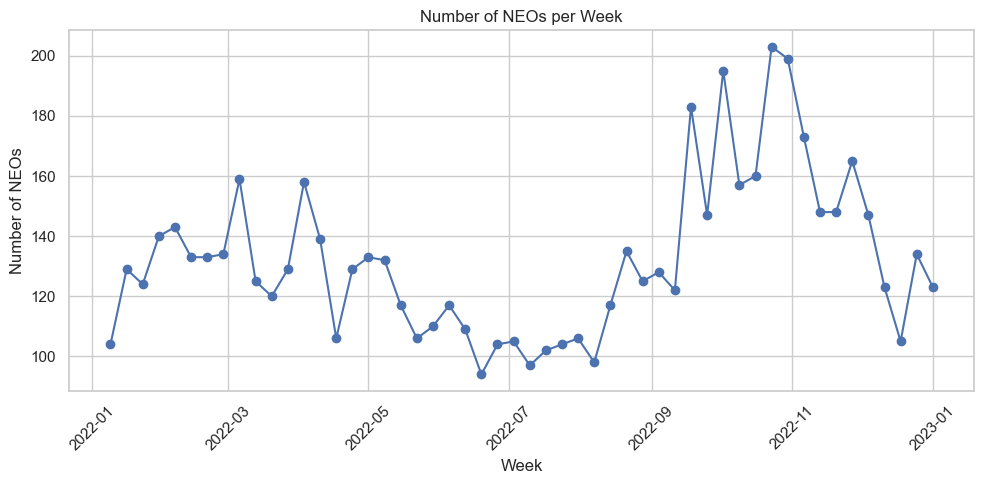

In [ ]:
#removing inconsistent week
weekly_neo_count_clean = weekly_neo_count.iloc[1:]

plt.figure(figsize=(10, 5))

#creating the plot
plt.plot(
    weekly_neo_count_clean["date"],
    weekly_neo_count_clean["neo_count"],
    marker="o"
)
# adding title + names
plt.title("Number of NEOs per Week")
plt.xlabel("Week")
plt.ylabel("Number of NEOs")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Note - The first weekly observation was removed because it represents an incomplete week at the beginning of the dataset. The value for 2022-01-02 is much lower than the following weeks because it only covers the first days of January, so including it would make the trend misleading.

**Interpretation:**  
This line plot shows how many NEOs were observed each week during the year. The number changes quite a lot from week to week. There is a low value at the very beginning, which is probably because the first week is not a full week in the dataset. After that, most weeks have somewhere around 110–180 NEOs.

The highest values appear around September and October, where several weeks have over 200 NEOs. I used a line plot because the data is ordered by time, so it makes sense to show the weekly changes as a trend instead of separate unrelated bars.

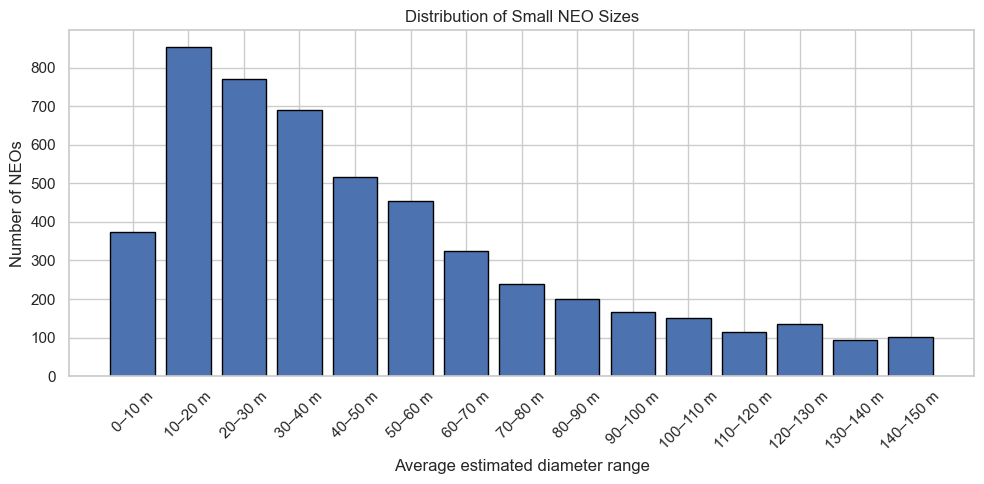

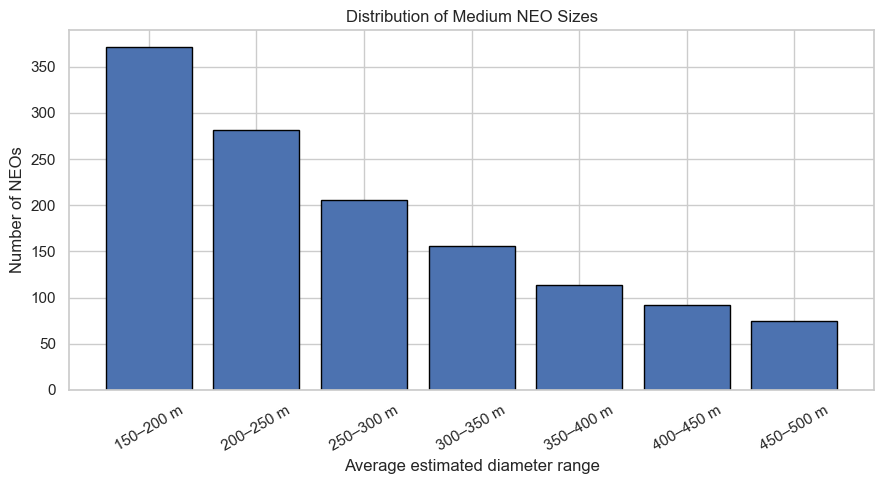


Maximum NEO size: 4.9835935705 km
Amount of datapoints: 6912


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

sizes = neo_df["diameter_avg_km"].dropna()
sizes = sizes[sizes > 0]

# Convert from km to meters
sizes_m = sizes * 1000

# -----------------------------
# Plot 1: 0–150 m, 10 m ranges
# -----------------------------

small_sizes = sizes_m[(sizes_m >= 0) & (sizes_m <= 150)]

bins_small = list(range(0, 151, 10))

labels_small = [
    f"{i}–{i+10} m"
    for i in range(0, 150, 10)
]

small_ranges = pd.cut(
    small_sizes,
    bins=bins_small,
    labels=labels_small,
    include_lowest=True
)

small_counts = small_ranges.value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(
    small_counts.index.astype(str),
    small_counts.values,
    edgecolor="black"
)

plt.title("Distribution of Small NEO Sizes")
plt.xlabel("Average estimated diameter range")
plt.ylabel("Number of NEOs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -------------------------------
# Plot 2: 150–500 m, 50 m ranges
# -------------------------------

medium_sizes = sizes_m[(sizes_m > 150) & (sizes_m <= 500)]

bins_medium = list(range(150, 501, 50))

labels_medium = [
    f"{i}–{i+50} m"
    for i in range(150, 500, 50)
]

medium_ranges = pd.cut(
    medium_sizes,
    bins=bins_medium,
    labels=labels_medium,
    include_lowest=True
)

medium_counts = medium_ranges.value_counts().sort_index()

plt.figure(figsize=(9, 5))

plt.bar(
    medium_counts.index.astype(str),
    medium_counts.values,
    edgecolor="black"
)

plt.title("Distribution of Medium NEO Sizes")
plt.xlabel("Average estimated diameter range")
plt.ylabel("Number of NEOs")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# -------------------------------
# Extra dataset information
# -------------------------------

print("")
print(f"Maximum NEO size: {neo_df['diameter_avg_km'].max()} km")
print(f"Amount of datapoints: {len(neo_df)}")

**Interpretation:**  
The two histograms show that most NEOs in the dataset are relatively small.  
For the small-size range, the highest number of NEOs is found around 10–40 meters, after which the count gradually decreases as the diameter increases.

The medium-size histogram shows the same pattern: NEOs between 150–200 meters are the most common, while larger NEOs become less frequent.  
Overall, this suggests that smaller near-Earth objects are much more common than larger ones.

### Average NEO size per week

We plot the weekly average NEO diameter to see how the typical size of observed NEOs changes over time.  
This gives a clearer overview of size trends than looking at individual NEOs one by one.

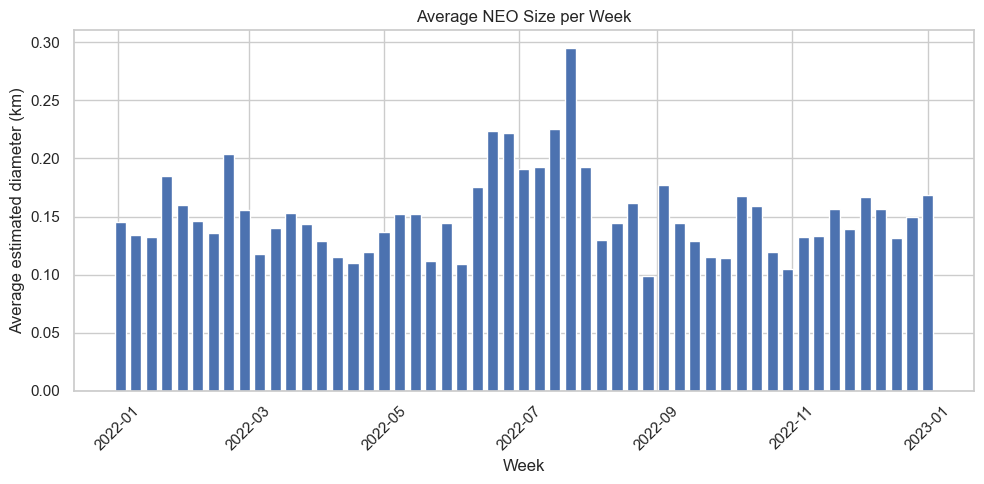

In [ ]:
plt.figure(figsize=(10, 5))

# Plot the average NEO diameter for each week as a bar chart
plt.bar(
    weekly_avg_size["date"],
    weekly_avg_size["average_diameter_km"],
    width=5
)

# olottet title and names
plt.title("Average NEO Size per Week")
plt.xlabel("Week")
plt.ylabel("Average estimated diameter (km)")

# Rotate x-axis name
plt.xticks(rotation=45)

# Adjust layout to prevent names from being cut off
plt.tight_layout()
plt.show()

**Interpretation:**  
This plot shows the average NEO size for each week. Most weeks are fairly close to each other, usually around 0.10–0.18 km, but there is a clear spike around July. This probably means that one or a few larger NEOs were observed in that week, which pulled the average up.

I used a bar plot because it makes it easy to compare the weekly averages. The graph is also kept simple, so the main thing that stands out is the July peak.

### NEO size by hazardous classification

We compare the size distribution of hazardous and non-hazardous NEOs using a boxplot.  
A logarithmic scale is used because NEO sizes vary a lot, making the comparison easier to read.

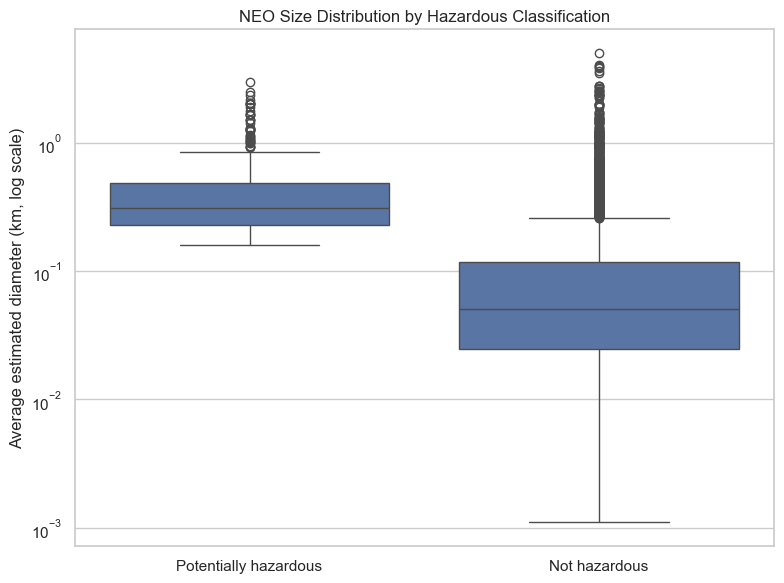

In [ ]:
plot_df = neo_df.copy()

# Convert the hazardous boolean values into readable labels for the plot
plot_df["Hazardous"] = plot_df["is_hazardous"].map({
    False: "Not hazardous",
    True: "Potentially hazardous"
})

# Create the figure
plt.figure(figsize=(8, 6))

# Create a boxplot comparing NEO sizes by hazardous classification
sns.boxplot(
    data=plot_df,
    x="Hazardous",
    y="diameter_avg_km"
)

# Use a logarithmic y-axis because NEO diameters vary greatly
plt.yscale("log")

# Add title and axis labels
plt.title("NEO Size Distribution by Hazardous Classification")
plt.xlabel("")
plt.ylabel("Average estimated diameter (km, log scale)")

# Adjust layout so labels are not cut off
plt.tight_layout()

# Display the plot
plt.show()

**Interpretation:**  
The boxplot shows that potentially hazardous NEOs are generally larger than non-hazardous NEOs.  
The median size for potentially hazardous NEOs is much higher, while most non-hazardous NEOs are smaller and spread across a wider range of sizes.

The y-axis uses a logarithmic scale because the diameters vary greatly.  
This makes it easier to compare both small and large NEOs in the same figure.

### NEO count heatmap

A heatmap is useful because it makes patterns easier to spot by using color intensity instead of only numbers.  
Here, darker cells show where more NEOs were observed.

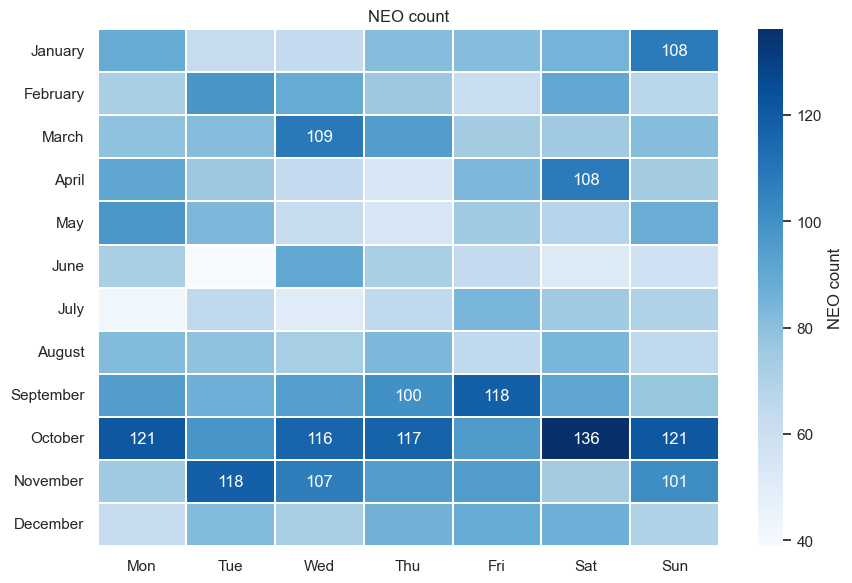

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copy data
heatmap_df = neo_df.copy()

# Make sure date is datetime
heatmap_df["date"] = pd.to_datetime(heatmap_df["date"])

# Extract month and weekday
heatmap_df["month"] = heatmap_df["date"].dt.month_name()
heatmap_df["weekday"] = heatmap_df["date"].dt.day_name()

# Count NEOs by month and weekday
neo_heatmap = (
    heatmap_df
    .groupby(["month", "weekday"])
    .size()
    .reset_index(name="neo_count")
)

# Correct order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
]

# Pivot to heatmap format
neo_heatmap_pivot = neo_heatmap.pivot(
    index="month",
    columns="weekday",
    values="neo_count"
)

# Reorder rows and columns
neo_heatmap_pivot = neo_heatmap_pivot.reindex(
    index=month_order,
    columns=weekday_order
)

# Rename weekday columns to reduce clutter
neo_heatmap_pivot.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Only show labels for high values
annot_labels = neo_heatmap_pivot.copy().astype(str)
annot_labels[neo_heatmap_pivot < 100] = ""

plt.figure(figsize=(9, 6))

sns.heatmap(
    neo_heatmap_pivot,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    linewidths=0.2,
    cbar_kws={"label": "NEO count"}
)

plt.title("NEO count")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Interpretation:**  
The heatmap shows the number of NEOs observed for each combination of month and weekday.  
Darker blue cells represent higher NEO counts, while lighter cells represent lower counts.

October stands out as one of the months with the highest number of NEO observations, especially on Monday, Wednesday, Thursday, Saturday, and Sunday.  
Some other high-count periods also appear in September and November.

The labels are only shown for values above 100 to keep the figure readable and avoid clutter.

**Textbook Practice**: You need to explain how the principles below are used for making this plot:
- "Choose an appropriate display" (Chapter 2)
- "Eliminate clutter" (Chapter 3)

In [45]:
# Write your code or/and markdowns

### Textbook Practice: Storytelling with Data principles

**Choose an appropriate display (Chapter 2)**  
A heatmap is an appropriate display here because the data has two categorical dimensions: month and weekday. Instead of using a large table of numbers, the heatmap keeps the table structure while using color intensity to show relative NEO counts. This matches the textbook’s explanation that heatmaps combine table detail with visual cues, making high and low values easier to spot quickly.

**Eliminate clutter (Chapter 3)**  
The plot reduces clutter by using a simple blue color scale, short weekday labels, no unnecessary axis titles, and annotations only for high values above 100. This keeps the focus on the important pattern instead of forcing the audience to read every single number. This follows the textbook principle that unnecessary visual elements increase cognitive load, so elements that do not add enough informative value should be removed.

Overall, the heatmap makes it easier to identify patterns in NEO observations across months and weekdays. Darker cells immediately guide the viewer toward higher counts, while the simplified labels and selective annotations keep the figure readable.

### Task 4: Data Visualization Part B

- Create a pie chart of the proportion of hazardous vs non-hazardous NEOs.
- Create a scatter plot of the correlation between NEO size and close approach distance.
- Customize the appearance of your plots (e.g., colors, labels, titles).
- Create interactive visualizations using a library like Plotly. For example, create an interactive scatter plot where you can hover over each point to see more information about the NEO. **Be creative!**

### Pie chart of the proportion of hazardous vs non-hazardous NEOs.

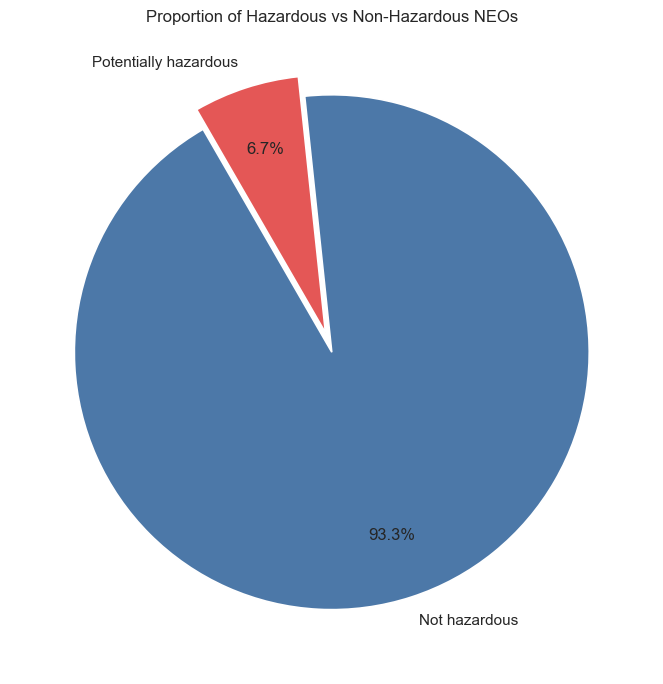

This pie chart shows the class balance: most NEOs are not hazardous, while a smaller share is potentially hazardous.


In [160]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data prep for Part B
viz_df = neo_df.copy()
viz_df = viz_df[(viz_df["diameter_avg_km"] > 0) & (viz_df["miss_distance_km"] > 0)].copy()
viz_df["hazard_label"] = viz_df["is_hazardous"].map({
    True: "Potentially hazardous",
    False: "Not hazardous"
})

sns.set_theme(style="whitegrid")

# Diagram 1: Pie chart (hazardous vs non-hazardous)
haz_counts = viz_df["hazard_label"].value_counts()
haz_counts = haz_counts.reindex(["Not hazardous", "Potentially hazardous"])

colors = ["#4C78A8", "#E45756"]
explode = (0.0, 0.08)

plt.figure(figsize=(7, 7))
plt.pie(
    haz_counts.values,
    labels=haz_counts.index,
    autopct="%1.1f%%",
    startangle=120,
    colors=colors,
    explode=explode,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2}
)
plt.title("Proportion of Hazardous vs Non-Hazardous NEOs")
plt.tight_layout()
plt.show()

print("This pie chart shows the class balance: most NEOs are not hazardous, while a smaller share is potentially hazardous.")


#### Diagram 2: Scatter plot (size vs close approach distance)
This plot shows the relationship between NEO size and close approach distance. Log scales are used to handle the wide range of values, and colors indicate hazardous classification.

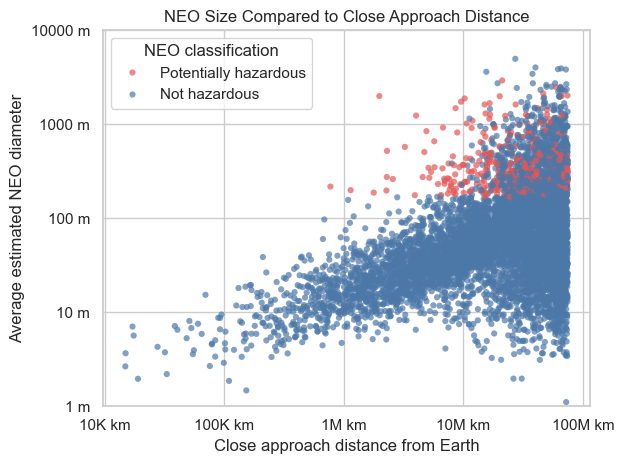

This scatter plot shows how NEO size and close approach distance relate to each other. Potentially hazardous NEOs are highlighted in red.


In [52]:
from matplotlib.ticker import FuncFormatter

# Convert x-axis numbers into readable distance labels
def format_distance(x, pos):
    if x >= 1_000_000:
        return f"{x/1_000_000:.0f}M km"
    elif x >= 1_000:
        return f"{x/1_000:.0f}K km"
    else:
        return f"{x:.0f} km"

# Convert y-axis labels from km to meters
def format_size(x, pos):
    return f"{x * 1000:.0f} m"


ax = sns.scatterplot(
    data=viz_df,
    x="miss_distance_km",
    y="diameter_avg_km",
    hue="hazard_label",
    s=20,
    alpha=0.7,
    palette={
        "Not hazardous": "#4C78A8",
        "Potentially hazardous": "#E45756"
    },
    edgecolor="none"
)

ax.set_xscale("log")
ax.set_yscale("log")

# Show y-axis up to 10 km = 10,000 m
ax.set_ylim(0.001, 10)

# Apply readable tick labels
ax.xaxis.set_major_formatter(FuncFormatter(format_distance))
ax.yaxis.set_major_formatter(FuncFormatter(format_size))

plt.title("NEO Size Compared to Close Approach Distance")
plt.xlabel("Close approach distance from Earth")
plt.ylabel("Average estimated NEO diameter")
plt.legend(title="NEO classification", frameon=True)
plt.tight_layout()
plt.show()

print("This scatter plot shows how NEO size and close approach distance relate to each other. Potentially hazardous NEOs are highlighted in red.")

#### Diagram 3: Interactive Plotly scatter
This interactive chart lets you hover over each NEO to inspect details (name, date, velocity, size, and distance) and explore the same relationship in more depth.

In [162]:
import plotly.express as px

fig = px.scatter(
    viz_df,
    x="miss_distance_km",
    y="diameter_avg_km",
    color="hazard_label",
    size="relative_velocity_kmh",
    hover_name="name",
    hover_data={
        "date": True,
        "relative_velocity_kmh": ":.0f",
        "miss_distance_km": ":.0f",
        "diameter_avg_km": ":.4f",
        "hazard_label": False
    },
    color_discrete_map={
        "Not hazardous": "#4C78A8",
        "Potentially hazardous": "#E45756"
    },
    title="Interactive NEOs: Size vs Distance (bubble size = velocity)",
    labels={
        "miss_distance_km": "Close approach distance (km)",
        "diameter_avg_km": "Average estimated diameter (km)",
        "relative_velocity_kmh": "Relative velocity (km/h)",
        "hazard_label": "Classification"
    }
)
fig.update_xaxes(type="log")
fig.update_yaxes(type="log")
fig.update_layout(legend_title_text="Classification", template="plotly_white")
fig.show()

print("This interactive plot supports deeper exploration by showing detailed NEO information on hover.")

This interactive plot supports deeper exploration by showing detailed NEO information on hover.


### Correlation matrix for better understanding

In [163]:
corr_df = viz_df.copy()
corr_df["hazard_numeric"] = corr_df["is_hazardous"].astype(int)

corr_cols = [
    "diameter_avg_km",
    "miss_distance_km",
    "hazard_numeric"
]

corr_matrix = corr_df[corr_cols].corr()
fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation Matrix: NEO Size, Close Approach Distance and Hazard",
    labels=dict(color="Correlation")
)

fig.update_layout(
    template="plotly_white",
    width=650,
    height=550
)

fig.show()

The correlation matrix shows only weak positive relationships, with NEO size having the strongest link to hazardous classification at 0.27.

In [164]:
import numpy as np
import plotly.express as px

# Creative diagram: "NEO Galaxy Wheel" with limiter for hazardous/high-impact observations
creative_df = viz_df.copy()
creative_df = creative_df[creative_df["miss_distance_km"] > 0].copy()

# Impact score (higher = potentially more critical)
# - closer distance should increase impact, so use inverse percentile for distance
creative_df["size_pct"] = creative_df["diameter_avg_km"].rank(pct=True)
creative_df["speed_pct"] = creative_df["relative_velocity_kmh"].rank(pct=True)
creative_df["distance_inverse_pct"] = 1 - creative_df["miss_distance_km"].rank(pct=True)

creative_df["impact_score"] = (
    0.45 * creative_df["distance_inverse_pct"]
    + 0.35 * creative_df["size_pct"]
    + 0.20 * creative_df["speed_pct"]
)

# Limiter: keep potentially hazardous OR top-impact observations
impact_cutoff = creative_df["impact_score"].quantile(0.90)
creative_df = creative_df[
    (creative_df["hazard_label"] == "Potentially hazardous")
    | (creative_df["impact_score"] >= impact_cutoff)
].copy()

# Optional hard cap so plot stays readable
creative_df = creative_df.nlargest(1200, "impact_score")

# Polar encoding
creative_df["day_of_year"] = creative_df["date"].dt.dayofyear
creative_df["theta_deg"] = (creative_df["day_of_year"] / 366.0) * 360
creative_df["log_miss_distance"] = np.log10(creative_df["miss_distance_km"])
creative_df["diameter_m"] = creative_df["diameter_avg_km"] * 1000
creative_df["month"] = creative_df["date"].dt.month_name()

fig_galaxy = px.scatter_polar(
    creative_df,
    r="log_miss_distance",
    theta="theta_deg",
    color="relative_velocity_kmh",
    size="diameter_m",
    symbol="hazard_label",
    hover_name="name",
    hover_data={
        "date": True,
        "hazard_label": True,
        "impact_score": ":.3f",
        "diameter_avg_km": ":.4f",
        "miss_distance_km": ":.0f",
        "relative_velocity_kmh": ":.0f",
        "theta_deg": False,
        "log_miss_distance": False,
        "diameter_m": False
    },
    color_continuous_scale="Turbo",
    opacity=0.82,
    title="NEO Galaxy Wheel — Hazardous & High-Impact Observations",
    labels={
        "log_miss_distance": "log10(close approach distance in km)",
        "relative_velocity_kmh": "Relative velocity (km/h)",
        "hazard_label": "Classification"
    }
)

# Keep bigger chart formatting
fig_galaxy.update_traces(marker=dict(sizemin=5, line=dict(width=0.4, color="rgba(255,255,255,0.35)")))

# Month labels on angular axis (instead of degree labels)
month_tickvals = [15, 45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345]
month_ticktext = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig_galaxy.update_layout(
    template="plotly_dark",
    width=1400,
    height=1000,
    title_font=dict(size=24),
    font=dict(size=14),
    margin=dict(l=30, r=30, t=90, b=30),
    polar=dict(
        radialaxis=dict(
            gridcolor="rgba(180,180,180,0.25)",
            linecolor="rgba(180,180,180,0.25)"
        ),
        angularaxis=dict(
            direction="clockwise",
            rotation=90,
            tickmode="array",
            tickvals=month_tickvals,
            ticktext=month_ticktext,
            gridcolor="rgba(180,180,180,0.18)",
            linecolor="rgba(180,180,180,0.18)"
        ),
        bgcolor="rgba(10,10,30,0.95)"
    ),
    legend_title_text="Hazard class",
    coloraxis_colorbar=dict(title="Velocity (km/h)")
)

fig_galaxy.show()

print(f"Limiter on: showing {len(creative_df)} hazardous/high-impact observations out of {len(viz_df)} total.")

Limiter on: showing 994 hazardous/high-impact observations out of 6912 total.


### How to read the NEO Galaxy Wheel

This visualization is a **polar chart**, which means each NEO is placed using an angle and a distance from the center.

- **Center of the wheel**  
  The center is the smallest value of the plotted radial variable and represents the **closest observed approach distances** in this chart.

- **Distance from center (radius)**  
  Radius is `log10(close approach distance in km)`.  
  - Points closer to the center = closer approach to Earth.  
  - Points farther out = larger miss distances.  
  Because this is on a log scale, equal visual steps represent multiplicative increases in distance, not linear ones.

- **Angle (month position around the wheel)**  
  The circular axis is labeled by **months** (Jan–Dec).  
  - Positions around the wheel correspond to the time of year.  
  - Within each month sector, points are still distributed by day, so you can see finer timing patterns.

- **Color**  
  Color shows **relative velocity (km/h)**.  
  Warmer/brighter colors correspond to faster objects.

- **Marker size**  
  Marker size reflects estimated **diameter** (in meters).  
  Larger circles indicate larger NEOs.

- **Marker symbol**  
  Symbol distinguishes **hazard classification** (`Potentially hazardous` vs `Not hazardous`).

### How to use this plot effectively

1. Look for points that are **closer to the center** (smaller miss distance).  
2. Among those, prioritize points that are **large** (bigger marker) and **fast** (warmer color).  
3. Use the symbol/legend to check whether they are flagged as potentially hazardous.  
4. Hover over points to inspect exact values (name, date, velocity, distance, size).

In short, the wheel helps combine **when** the NEO appears (month/angle), **how close** it gets (radius), **how big** it is (size), and **how fast** it moves (color) in one view.

In [165]:
import numpy as np
import plotly.graph_objects as go

# ==============================================================
# Ultra-creative bonus: 3D NEO Fly-By Simulator (animated world)
# High-impact only edition
# ==============================================================

# Rebuild from full Part B data to keep ALL high-impact objects
world_df = viz_df.copy()
world_df = world_df[world_df["miss_distance_km"] > 0].copy()

# Ensure impact score exists for full dataset
world_df["size_pct"] = world_df["diameter_avg_km"].rank(pct=True)
world_df["speed_pct"] = world_df["relative_velocity_kmh"].rank(pct=True)
world_df["distance_inverse_pct"] = 1 - world_df["miss_distance_km"].rank(pct=True)
world_df["impact_score"] = (
    0.45 * world_df["distance_inverse_pct"]
    + 0.35 * world_df["size_pct"]
    + 0.20 * world_df["speed_pct"]
)

# Keep only high-impact (top 10%)
impact_cutoff_world = world_df["impact_score"].quantile(0.99)
world_df = world_df[world_df["impact_score"] >= impact_cutoff_world].copy()
world_df = world_df.sort_values("impact_score", ascending=False).reset_index(drop=True)

# Deterministic pseudo-orbital setup based on time + index
n = len(world_df)
idx = np.arange(n)

day = world_df["date"].dt.dayofyear.to_numpy()
miss_km = world_df["miss_distance_km"].to_numpy()
vel = world_df["relative_velocity_kmh"].to_numpy()
diam_m = (world_df["diameter_avg_km"].to_numpy() * 1000)

# Distances expressed in million km for scene readability
start_dist = np.clip(miss_km / 1_000_000, 0.35, 14.0)

# Angle around Earth from day-of-year; inclination from velocity percentile + index phase
theta = 2 * np.pi * (day / 366.0)
vel_rank = (world_df["relative_velocity_kmh"].rank(pct=True).to_numpy() - 0.5) * 1.3
incl = np.clip(vel_rank + 0.25 * np.sin(idx * 0.37), -1.0, 1.0)

# Initial position vectors
x0 = start_dist * np.cos(theta) * np.cos(incl)
y0 = start_dist * np.sin(theta) * np.cos(incl)
z0 = start_dist * np.sin(incl)
start_vec = np.column_stack([x0, y0, z0])

# Tangent direction (roughly orbital sideways motion)
tangent = np.column_stack([-y0, x0, np.zeros(n)])
tangent_norm = np.linalg.norm(tangent, axis=1, keepdims=True)
tangent_norm[tangent_norm == 0] = 1
tangent = tangent / tangent_norm

# Secondary axis for swirl (binormal-like)
binormal = np.cross(start_vec, tangent)
binorm_norm = np.linalg.norm(binormal, axis=1, keepdims=True)
binorm_norm[binorm_norm == 0] = 1
binormal = binormal / binorm_norm

# Closest-pass factor from impact score
score = world_df["impact_score"].to_numpy()
score_norm = (score - score.min()) / (score.max() - score.min() + 1e-9)
closest_factor = np.clip(0.12 + (1 - score_norm) * 0.42, 0.06, 0.65)

# Hazardous objects get an extra close pass
haz_boost = np.where(world_df["hazard_label"].to_numpy() == "Potentially hazardous", 0.82, 1.0)
closest_factor = np.clip(closest_factor * haz_boost, 0.06, 0.65)

# Marker sizes
marker_size = np.clip(3 + np.sqrt(np.clip(diam_m, 1, None)) / 3.0, 4, 20)

# Hover text
hover_text = (
    "<b>" + world_df["name"].astype(str) + "</b><br>" +
    "Date: " + world_df["date"].dt.strftime("%Y-%m-%d") + "<br>" +
    "Class: " + world_df["hazard_label"].astype(str) + "<br>" +
    "Impact score: " + world_df["impact_score"].round(3).astype(str) + "<br>" +
    "Velocity: " + world_df["relative_velocity_kmh"].round(0).astype(int).astype(str) + " km/h<br>" +
    "Diameter: " + (world_df["diameter_avg_km"] * 1000).round(1).astype(str) + " m<br>" +
    "Miss distance: " + world_df["miss_distance_km"].round(0).astype(int).astype(str) + " km"
)

# Earth sphere (radius in scene units: million km)
earth_r = 0.12
u = np.linspace(0, 2 * np.pi, 60)
v = np.linspace(0, np.pi, 30)
xs = earth_r * np.outer(np.cos(u), np.sin(v))
ys = earth_r * np.outer(np.sin(u), np.sin(v))
zs = earth_r * np.outer(np.ones_like(u), np.cos(v))

# Atmosphere shell
atm_r = earth_r * 1.13
xsa = atm_r * np.outer(np.cos(u), np.sin(v))
ysa = atm_r * np.outer(np.sin(u), np.sin(v))
zsa = atm_r * np.outer(np.ones_like(u), np.cos(v))

# Star field for extra cosmic vibes
star_n = 900
rng = np.random.default_rng(42)
star_xyz = rng.uniform(-16, 16, size=(star_n, 3))
star_size = rng.uniform(1, 2.2, size=star_n)

# Build animated frames
n_frames = 64
t_vals = np.linspace(0, 1, n_frames)
phase = idx * 0.41
spiral_amp = np.clip(start_dist * 0.11, 0.05, 1.35)

frames = []
for t in t_vals:
    # Fly-by profile: approach to closest point then depart
    if t <= 0.5:
        k = t / 0.5
        radial_scale = 1 - (1 - closest_factor) * k
    else:
        k = (t - 0.5) / 0.5
        radial_scale = closest_factor + (1.35 - closest_factor) * k

    swirl1 = (spiral_amp * np.sin(2 * np.pi * (t + phase)))[:, None] * tangent
    swirl2 = (0.75 * spiral_amp * np.cos(2 * np.pi * (t + phase)))[:, None] * binormal

    pos = start_vec * radial_scale[:, None] + swirl1 + swirl2

    frames.append(
        go.Frame(
            data=[
                go.Scatter3d(
                    x=pos[:, 0],
                    y=pos[:, 1],
                    z=pos[:, 2],
                    mode="markers",
                    marker=dict(
                        size=marker_size,
                        color=vel,
                        colorscale="Turbo",
                        cmin=float(np.min(vel)),
                        cmax=float(np.max(vel)),
                        opacity=0.92,
                        line=dict(width=0.4, color="rgba(255,255,255,0.35)"),
                        colorbar=dict(title="Velocity (km/h)", x=1.02)
                    ),
                    text=hover_text,
                    hovertemplate="%{text}<extra></extra>"
                )
            ],
            traces=[4],
            name=f"f{int(t * 1000)}"
        )
    )

# Initial asteroid positions
pos0 = start_vec + (
    (spiral_amp * np.sin(2 * np.pi * phase))[:, None] * tangent +
    (0.75 * spiral_amp * np.cos(2 * np.pi * phase))[:, None] * binormal
)

fig_world = go.Figure()

# 0) Stars
fig_world.add_trace(
    go.Scatter3d(
        x=star_xyz[:, 0], y=star_xyz[:, 1], z=star_xyz[:, 2],
        mode="markers",
        marker=dict(size=star_size, color="rgba(255,255,255,0.8)"),
        hoverinfo="skip",
        showlegend=False
    )
)

# 1) Earth
fig_world.add_trace(
    go.Surface(
        x=xs, y=ys, z=zs,
        colorscale=[[0, "#003366"], [0.35, "#1b6ca8"], [0.7, "#36c486"], [1, "#b0f0ff"]],
        showscale=False,
        opacity=0.98,
        lighting=dict(ambient=0.35, diffuse=0.85, specular=0.6, roughness=0.7, fresnel=0.35),
        lightposition=dict(x=120, y=-80, z=60),
        name="Earth"
    )
)

# 2) Atmosphere glow
fig_world.add_trace(
    go.Surface(
        x=xsa, y=ysa, z=zsa,
        colorscale=[[0, "rgba(100,180,255,0.08)"], [1, "rgba(120,210,255,0.22)"]],
        showscale=False,
        opacity=0.22,
        hoverinfo="skip",
        name="Atmosphere"
    )
)

# 3) Earth core glow point
fig_world.add_trace(
    go.Scatter3d(
        x=[0], y=[0], z=[0],
        mode="markers",
        marker=dict(size=5, color="#bffcff", opacity=0.9),
        name="Earth center",
        hovertemplate="Earth<extra></extra>"
    )
)

# 4) Animated asteroids
fig_world.add_trace(
    go.Scatter3d(
        x=pos0[:, 0], y=pos0[:, 1], z=pos0[:, 2],
        mode="markers",
        marker=dict(
            size=marker_size,
            color=vel,
            colorscale="Turbo",
            cmin=float(np.min(vel)),
            cmax=float(np.max(vel)),
            opacity=0.92,
            line=dict(width=0.4, color="rgba(255,255,255,0.35)"),
            colorbar=dict(title="Velocity (km/h)", x=1.02)
        ),
        text=hover_text,
        hovertemplate="%{text}<extra></extra>",
        name="High-impact NEOs"
    )
)

fig_world.frames = frames

fig_world.update_layout(
    title="🚀 High-Impact NEO Fly-By World (3D) — Top Impact Objects Only",
    template="plotly_dark",
    width=1500,
    height=980,
    margin=dict(l=0, r=0, t=70, b=0),
    scene=dict(
        xaxis=dict(visible=False, range=[-16, 16]),
        yaxis=dict(visible=False, range=[-16, 16]),
        zaxis=dict(visible=False, range=[-16, 16]),
        aspectmode="cube",
        bgcolor="rgba(5,8,20,1)"
    ),
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.02,
            y=0.02,
            direction="left",
            buttons=[
                dict(
                    label="▶ Play Fly-By",
                    method="animate",
                    args=[None, dict(frame=dict(duration=75, redraw=False), transition=dict(duration=0), fromcurrent=True)]
                ),
                dict(
                    label="⏸ Pause",
                    method="animate",
                    args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate", transition=dict(duration=0))]
                )
            ]
        )
    ],
    sliders=[
        dict(
            x=0.16,
            y=0.02,
            len=0.75,
            currentvalue=dict(prefix="Time step: "),
            steps=[
                dict(
                    label=str(i + 1),
                    method="animate",
                    args=[[fr.name], dict(mode="immediate", frame=dict(duration=0, redraw=False), transition=dict(duration=0))]
                )
                for i, fr in enumerate(frames)
            ]
        )
    ]
)

fig_world.show()
print(
    f"High-impact filter on: showing {n} NEOs "
    f"(impact score >= {impact_cutoff_world:.3f}, top 10% of all observations)."
)

High-impact filter on: showing 70 NEOs (impact score >= 0.782, top 10% of all observations).


**Textbook Practice**: You need to explain how the principle "Draw attention there you want it" (Chapter 4) is applied for making all the visualizations.

### Chapter 4 — Draw attention where you want it

In Part B, the visual design guides the reader to the main message: **potentially hazardous NEOs are fewer, but important to focus on**.

The principle “Draw attention where you want it” is applied in all three visualizations by using preattentive attributes to guide the viewer’s eye toward the most important parts of the data. In Chapter 4, Focus your audience’s attention, Knaflic explains that visual elements such as color, size, intensity, spatial position, and added marks can be used strategically to make the audience notice important information quickly. She also explains that these attributes help create a visual hierarchy, meaning that the viewer is guided through the visualization in the order intended by the designer. 

#### In the scatter plots
The most important use of this principle is color. Potentially hazardous NEOs are shown in red, while non-hazardous NEOs are shown in blue. This makes the hazardous objects stand out immediately because red creates strong contrast against the large number of blue points. This follows one of Knaflic’s points, she explains that our brains quickly notice what is visually different before we consciously process it. In other words, the red points act as a “look here” signal.  

The visualizations also use hue as a categorical differentiator. Knaflic notes that color is not ideal for showing quantitative value, because “red” is not naturally more or less than “blue.” Instead, color works well for separating categories. This is exactly what happens here: red and blue do not represent numerical size, but classify the objects as potentially hazardous or not hazardous. This makes the classification clear without forcing the audience to search through the data manually.  

#### Interactive scatterplot
The interactive scatter plot also applies the principle through size. The bubble size represents velocity, so faster objects become more visually prominent. This connects to Knaflic’s discussion of size as a preattentive attribute. In the chapter she explains that relative size communicates relative importance, and that important elements can be made larger to attract attention. In this graph, larger bubbles naturally draw the viewer’s eye and add another layer of meaning without needing a separate chart. And since its interactive, its also possible to only look at the hazardous and not hazardous observations. 

The use of logarithmic scales also helps focus attention. Since both close approach distance and estimated diameter vary greatly, the log scale prevents the data from becoming compressed in one area. This improves readability and reduces the effort required from the viewer. Although the log scale is not itself one of Knaflic’s main preattentive attributes, it supports the same goal: it reduces visual confusion and makes patterns easier to see.

##### Analysis
In the pie chart, the principle is applied through contrast, color, and proportion. The red slice represents the potentially hazardous NEOs and is much smaller than the blue slice. Because it is red and separated slightly from the larger blue area, the viewer’s attention is drawn to the 6.7% hazardous group. The percentage labels also act as added marks, making the key comparison easier to understand. The chart communicates the main message quickly: only a small proportion of the NEOs are potentially hazardous, while the majority, 93.3%, are not hazardous.

Knaflic also emphasizes that color should be used sparingly and intentionally. She warns that too many colors reduce the power of color as a preattentive attribute, because if everything stands out, nothing stands out. These visualizations follow that advice by using only two main colors: red for hazardous objects and blue for non-hazardous objects. This keeps the design simple and makes the important category stand out clearly.  

Overall, the visualizations apply “Draw attention where you want it” by using preattentive attributes, especially color, size, contrast, and added marks, to guide the audience toward the most important message. The red color highlights the potentially hazardous NEOs, the bubble size adds focus to velocity in the interactive scatter plot, and the percentage labels in the pie chart make the main proportion easy to read. These choices create a clear visual hierarchy and help the audience move from simply seeing data to understanding the story in the data.

### Task 5: Interpretation of Results

- Interpret the results of your data visualization in part A and B. 
- What insights can you gain about NEOs from your results? Summarizing your main findings with a single visualization plot. **Textbook Practice**: You need to explain how the principles below are used for making this plot:
  - "Choose an appropriate display" (Chapter 2)
  - "Eliminate clutter" (Chapter 3)
  - "Draw attention there you want it" (Chapter 4)
  - "Think like a designer" (Chapter 5)

- Use your findings to make predictions or recommendations. For example, if you found that larger NEOs are more likely to be potentially hazardous, you could recommend that more resources be allocated to tracking large NEOs. **Be creative!**
- Identify, understand, and explain one scientific paper, on a clustering or classification method of relevance that could help Task 5. You don't have to implement it, you just need to justify in this notebook why the method in the scientific paper could contribute in analysis or interpretation of the results.

In [166]:
# Write your code and markdowns

## Interpret the results of your data visualization in Part A and Part B

The visualizations from Part A and Part B together show a consistent pattern: **most Near-Earth Objects (NEOs) are small and non-hazardous, while potentially hazardous objects tend to be larger and deserve focused attention**.

In **Part A**, the weekly trend plot shows that NEO observations vary over time, with periods of higher activity (especially around early autumn). The size-distribution plots show a strongly right-skewed distribution: most NEOs are relatively small, with a long tail of larger objects. The weekly average-size plot is mostly stable but includes occasional spikes, indicating that one or a few large objects can strongly affect the mean in a given week. The boxplot comparison (hazardous vs non-hazardous) supports the statistical findings: the hazardous group generally has a higher median size and a wider upper spread.

In **Part B**, the pie chart confirms class imbalance: only a small minority of objects are classified as potentially hazardous. The scatter plots (static and interactive) show that size, distance, and velocity vary substantially across observations. Hazardous objects are not defined by a single feature alone, but larger diameter and high-impact combinations (larger size + higher velocity + lower miss distance) are visually more concerning. The interactive and creative plots strengthen interpretation by allowing detailed inspection of individual objects rather than only aggregate summaries.

Overall, the results indicate that hazard assessment is **multifactorial**, but object size appears to be an important signal and should remain central in monitoring priorities.

## What insights can be gained from these results? Main findings summarized with one visualization

The main insight from our visual analysis is that potentially hazardous Near-Earth Objects (NEOs) tend to be larger than non-hazardous NEOs, while close approach distance alone does not appear to be a strong indicator of hazard classification.

Our correlation matrix supports this finding. The correlation between average estimated diameter and hazard classification is **0.27**, while the correlation between close approach distance and hazard classification is only **0.09**. This means that NEO size has a stronger relationship with hazard classification than distance does, although the correlation is still not very strong. The correlation between NEO size and close approach distance is **0.25**, which suggests a weak positive relationship, but the scatter plot shows that there is still a large amount of variation in the data.

The most important visualization is the scatter plot showing **NEO size versus close approach distance**, with points colored by hazard classification. This plot is useful because it combines the three most important variables in one display: average estimated diameter, close approach distance, and whether the object is potentially hazardous. The plot shows that hazardous NEOs are generally located higher on the y-axis, meaning they tend to have larger estimated diameters. However, they are not only found at the shortest distances, which supports the conclusion that hazard classification is not determined by close approach distance alone.

Another important finding is that the dataset is highly imbalanced. The pie chart shows that only **6.7%** of the NEOs are classified as potentially hazardous, while **93.3%** are non-hazardous. This makes it especially important that the visualization draws attention to the hazardous objects, since they represent a small minority of the dataset.

Overall, our results suggest that hazard assessment is multifactorial. However, size appears to be one of the most important signals in the data. Potentially hazardous NEOs are generally larger, while close approach distance by itself is a weak predictor of hazard.

## Single visualization used to summarize the main finding
We chose the scatter plot of **NEO size vs close approach distance**, colored by hazard classification, as our main visualization.

This visualization best summarizes our findings because it shows both the relationship between size and distance and how this relationship differs for hazardous and non-hazardous NEOs. Each point represents one NEO observation. The x-axis shows close approach distance, the y-axis shows average estimated diameter, and the color shows whether the object is potentially hazardous.

The main message of the plot is that potentially hazardous NEOs tend to be larger than non-hazardous NEOs. At the same time, the plot shows that close approach distance alone does not clearly separate hazardous from non-hazardous objects. This supports the result from the correlation matrix, where the correlation between size and hazard is stronger than the correlation between distance and hazard.

#### Choose an appropriate display
Following the principle **“Choose an appropriate visual display”** from Chapter 2, we selected a scatter plot because our goal was to examine the relationship between two numerical variables: NEO size and close approach distance. A scatter plot is appropriate because it allows each NEO to be shown as an individual observation, making it possible to see patterns, clusters, spread, and outliers.

A bar chart would not be as suitable because it would aggregate the data too much and hide the distribution of individual NEOs. A pie chart would only show the proportion of hazardous and non-hazardous objects, but it would not show how size and distance relate to hazard classification. The scatter plot therefore matches the analytical question better because the relationship between variables is the focus.

#### Eliminate clutter
Following Chapter 3, **“Eliminate clutter”**, the visualization focuses only on the elements that support the main message. The plot uses clear axis labels, a simple legend, and a limited number of visual encodings. Unnecessary decoration is avoided so that the viewer can focus on the data itself.

The use of log scales also reduces visual clutter because the NEO values vary across several orders of magnitude. Without log scaling, many points would be compressed into a small part of the chart, making the pattern harder to see. By using log scales, the visualization becomes easier to read and the spread of both small and large objects becomes more visible.

#### Draw attention where you want it

Following Chapter 4, **“Draw attention where you want it”**, color is used as a preattentive attribute to highlight the most important category: potentially hazardous NEOs. The hazardous objects are colored red, which immediately draws the viewer’s attention. The non-hazardous objects are shown in blue, providing context without dominating the visual.

This creates a clear visual hierarchy. The viewer first notices the hazardous objects, then compares their position with the rest of the dataset. This makes it easier to see that hazardous NEOs tend to have larger diameters, while close approach distance alone does not clearly separate the two groups.

#### Think like a designer

Following Chapter 5, **“Think like a designer”**, the visualization is designed around its function. The purpose of the plot is not just to show data, but to help the audience understand what separates potentially hazardous NEOs from non-hazardous ones. In the words of the textbook principle, the form follows the function.

The plot uses a clear title, meaningful axis labels, log scaling, and simple color coding. These design choices make the visualization accessible and easier to interpret. The design also supports the main story of the data: potentially hazardous NEOs are generally larger, but hazard classification cannot be explained by distance alone.


## Conclusion
The final visualization shows that potentially hazardous NEOs are generally larger than non-hazardous NEOs. This is supported by the correlation matrix, where average diameter has a stronger correlation with hazard classification than close approach distance does.

However, the correlations are not strong enough to conclude that hazard can be explained by one variable alone. Instead, the results suggest that hazard classification depends on multiple factors, with NEO size being an important part of the pattern.

Therefore, the key finding is:

**Potentially hazardous NEOs are usually larger, but close approach distance alone is not enough to determine whether a NEO is hazardous.**

## Predictions and recommendations based on the findings
Based on our findings, larger NEOs appear more likely to be classified as potentially hazardous than smaller NEOs. The correlation matrix showed a stronger relationship between average estimated diameter and hazard classification than between close approach distance and hazard classification. This suggests that size should be treated as an important early warning signal when prioritizing which NEOs to monitor more closely.

A practical recommendation is to allocate more tracking resources to larger NEOs, especially when they also have relatively low miss distances or high relative velocities. Instead of treating all NEOs equally, space agencies could use a priority score that combines several attributes:

**Priority score = size + closeness + velocity + uncertainty**

For example, a large NEO passing moderately close to Earth could receive a higher monitoring priority than a very small NEO passing at the same distance. This is important because our results suggest that close approach distance alone is not enough to explain hazard classification.

A creative recommendation would be to develop a simple “NEO traffic light system”:

- **Green:** Small NEOs with large miss distances and low relative velocity.
- **Yellow:** Medium-sized NEOs or objects with uncertain measurements.
- **Red:** Large NEOs with lower miss distance, higher velocity, or missing/uncertain data.

This system could help researchers and the public quickly understand which objects deserve the most attention. It would also make the data easier to communicate, since the current dataset is highly imbalanced and most NEOs are non-hazardous.

Based on the visualizations, we would predict that future potentially hazardous NEOs are more likely to appear among objects with larger estimated diameters, especially when combined with other risk-related factors such as close approach distance and relative velocity. Therefore, our recommendation is not only to track the closest objects, but to prioritize larger objects and objects with multiple concerning features.

## Prediction and recommendation

Our results suggest that larger NEOs are more likely to be classified as potentially hazardous. Therefore, we predict that future potentially hazardous NEOs will more often be found among objects with larger estimated diameters, especially when combined with low miss distance or high relative velocity.

We recommend using a priority-based monitoring system instead of focusing on one variable alone. NEOs should be ranked using a combination of size, miss distance, velocity, and measurement uncertainty. A creative solution could be a “traffic light system” where green objects require low attention, yellow objects require continued monitoring, and red objects require high-priority tracking.

This recommendation follows from our finding that hazard assessment is multifactorial. Size appears to be an important signal, but close approach distance alone is not enough to determine whether a NEO is potentially hazardous.

## Scientific paper: Classification of dangerous asteroids using machine learning

A relevant scientific paper for this task is **Malakouti (2023), “Machine learning techniques for classifying dangerous asteroids”**. The paper is relevant because it works with a similar problem to ours: using asteroid data to classify objects as more or less dangerous.

The paper classifies “high-risk and low-risk asteroids” and tests several machine learning models, including “Lightgbm, Gradient Boosting, Ada Boost, Extra Tree, and Random Forest.” This connects well to our notebook because we also look at features such as estimated diameter, close approach distance, relative velocity, and hazardous classification.

Our results show that potentially hazardous NEOs are generally larger than non-hazardous NEOs. However, the correlation is not strong enough to say that size alone explains whether a NEO is hazardous. This is where a classification method could be useful, because a model such as Random Forest can combine several variables at the same time instead of only looking at one feature.

The paper reports that the “Random Forest algorithm predicted high-risk asteroids with 94% accuracy.” This suggests that machine learning classification can be useful for asteroid hazard analysis. For our project, such a method could help check whether diameter, miss distance, velocity, or a combination of these variables gives the best prediction of hazardous classification.

We do not implement the model in this notebook, but it could be a useful next step. If a model showed that diameter and close approach distance were the most important features, it would support our recommendation that larger NEOs with close approaches should be prioritized for tracking.

link: https://pmc.ncbi.nlm.nih.gov/articles/PMC10480302/